In [155]:
import pandas as pd

In [156]:
fleet_df = pd.read_csv("../data_pack/turbine_90_cleaned.csv")
fleet_df.head()

,timestamp,turbine_id,wind_speed,power_kw,availability,wind_speed_clean,power_anomaly_flag,power_kw_clean
0,2026-03-01 00:00:00,T01,7.11,198.3,1.0,7.11,0,198.3
1,2026-03-01 00:00:00,T02,5.42,25.6,1.0,5.42,0,25.6
2,2026-03-01 00:00:00,T03,8.31,393.2,1.0,8.31,0,393.2
3,2026-03-01 00:00:00,T04,4.82,11.3,1.0,4.82,0,11.3
4,2026-03-01 00:00:00,T05,4.24,27.3,1.0,4.24,0,27.3


In [157]:
fleet_df = (
    df_clean
    .groupby("timestamp")
    .agg(
        total_power_kw=("power_kw_clean", "sum"),
        mean_wind_speed=("wind_speed_clean", "mean"),
        available_turbines=("availability", "sum"),
        anomalous_turbines=("power_anomaly_flag", "sum")
    )
    .reset_index()
)

In [158]:
fleet_df.shape

(2145, 5)

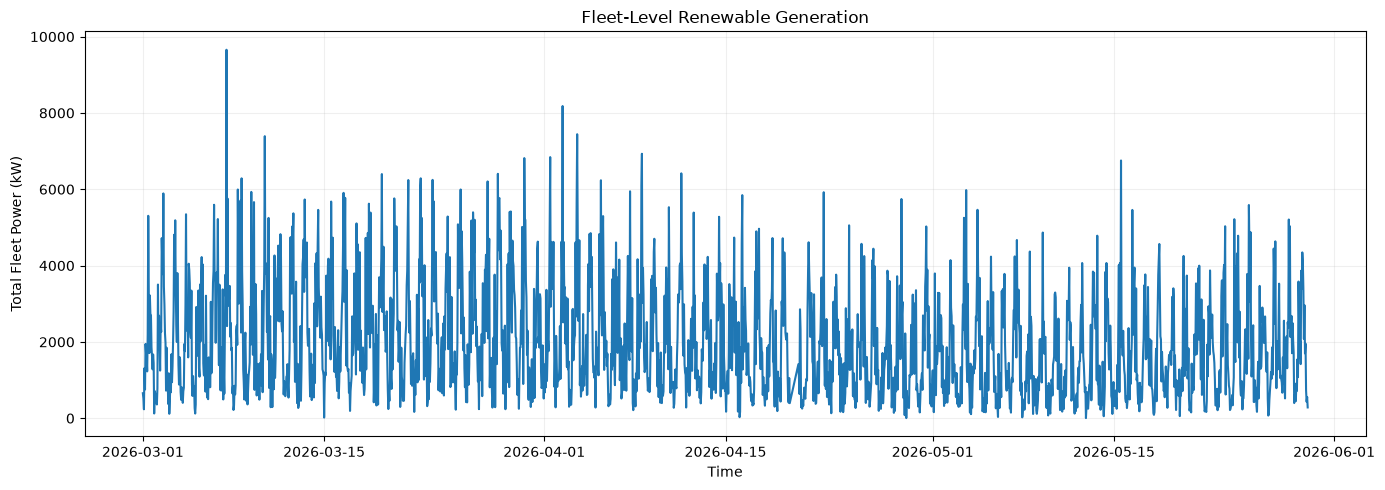

In [159]:
plt.figure(figsize=(14, 5))

plt.plot(
    fleet_df["timestamp"],
    fleet_df["total_power_kw"]
)

plt.xlabel("Time")
plt.ylabel("Total Fleet Power (kW)")
plt.title("Fleet-Level Renewable Generation")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [160]:
fleet_df.head()

,timestamp,total_power_kw,mean_wind_speed,available_turbines,anomalous_turbines
0,2026-03-01 00:00:00,655.7,5.980,5.0,0
1,2026-03-01 01:00:00,520.8,5.846,5.0,0
2,2026-03-01 02:00:00,234.3,5.444,5.0,0
3,2026-03-01 03:00:00,1312.6,7.178,5.0,0
4,2026-03-01 04:00:00,752.6,4.970,5.0,0


In [161]:
# Make sure data is sorted
fleet_df = fleet_df.sort_values("timestamp").reset_index(drop=True)

# Create the expected complete hourly timeline
full_hours = pd.date_range(
    start=fleet_df["timestamp"].min(),
    end=fleet_df["timestamp"].max(),
    freq="h"
)

print("Expected hourly timestamps:", len(full_hours))
print("Observed hourly timestamps:", len(fleet_df))

Expected hourly timestamps: 2160
Observed hourly timestamps: 2145


In [162]:
missing_hours = full_hours.difference(
    fleet_df["timestamp"]
)

print("Number of missing hours:", len(missing_hours))
print(missing_hours)

Number of missing hours: 15
DatetimeIndex(['2026-04-20 00:00:00', '2026-04-20 01:00:00',
               '2026-04-20 02:00:00', '2026-04-20 03:00:00',
               '2026-04-20 04:00:00', '2026-04-20 05:00:00',
               '2026-04-20 06:00:00', '2026-04-20 07:00:00',
               '2026-04-20 08:00:00', '2026-04-20 09:00:00',
               '2026-04-20 10:00:00', '2026-04-20 11:00:00',
               '2026-04-20 12:00:00', '2026-04-20 13:00:00',
               '2026-04-20 14:00:00'],
              dtype='datetime64[us]', freq='h')


In [163]:
fleet_ts = (
    fleet_df
    .set_index("timestamp")
    .reindex(full_hours)
    .rename_axis("timestamp")
    .reset_index()
)

In [164]:
print(fleet_ts.shape)
fleet_ts.head()

(2160, 5)


,timestamp,total_power_kw,mean_wind_speed,available_turbines,anomalous_turbines
0,2026-03-01 00:00:00,655.7,5.980,5.0,0.0
1,2026-03-01 01:00:00,520.8,5.846,5.0,0.0
2,2026-03-01 02:00:00,234.3,5.444,5.0,0.0
3,2026-03-01 03:00:00,1312.6,7.178,5.0,0.0
4,2026-03-01 04:00:00,752.6,4.970,5.0,0.0


In [165]:
fleet_ts[
    fleet_ts["total_power_kw"].isna()
][["timestamp", "total_power_kw"]]

,timestamp,total_power_kw
1200,2026-04-20 00:00:00,NaN
1201,2026-04-20 01:00:00,NaN
1202,2026-04-20 02:00:00,NaN
1203,2026-04-20 03:00:00,NaN
1204,2026-04-20 04:00:00,NaN
1205,2026-04-20 05:00:00,NaN
1206,2026-04-20 06:00:00,NaN
1207,2026-04-20 07:00:00,NaN
1208,2026-04-20 08:00:00,NaN
1209,2026-04-20 09:00:00,NaN


In [166]:
print(
    "Missing target values:",
    fleet_ts["total_power_kw"].isna().sum()
)

Missing target values: 15


In [167]:
gap_check = fleet_ts[
    (
        fleet_ts["timestamp"] >= "2026-04-19 18:00:00"
    ) &
    (
        fleet_ts["timestamp"] <= "2026-04-20 20:00:00"
    )
][[
    "timestamp",
    "total_power_kw",
    "mean_wind_speed",
    "available_turbines"
]]

gap_check

,timestamp,total_power_kw,mean_wind_speed,available_turbines
1194,2026-04-19 18:00:00,2221.4,7.636,5.0
1195,2026-04-19 19:00:00,1183.8,6.540,5.0
1196,2026-04-19 20:00:00,492.7,5.644,5.0
1197,2026-04-19 21:00:00,408.4,5.592,5.0
1198,2026-04-19 22:00:00,1053.2,6.208,5.0
1199,2026-04-19 23:00:00,394.8,5.440,5.0
1200,2026-04-20 00:00:00,NaN,NaN,NaN
1201,2026-04-20 01:00:00,NaN,NaN,NaN
1202,2026-04-20 02:00:00,NaN,NaN,NaN
1203,2026-04-20 03:00:00,NaN,NaN,NaN


In [168]:
fleet_ts["lag_24_check"] = (
    fleet_ts["timestamp"] - pd.Timedelta(hours=24)
)

lag_lookup = fleet_ts[
    ["timestamp", "total_power_kw"]
].copy()

lag_lookup = lag_lookup.rename(
    columns={
        "timestamp": "lag_timestamp",
        "total_power_kw": "lag_power"
    }
)

fleet_ts_check = fleet_ts.merge(
    lag_lookup,
    left_on="lag_24_check",
    right_on="lag_timestamp",
    how="left"
)

fleet_ts_check[
    fleet_ts_check["lag_power"].isna()
][[
    "timestamp",
    "lag_24_check",
    "total_power_kw",
    "lag_power"
]].head(30)

,timestamp,lag_24_check,total_power_kw,lag_power
0,2026-03-01 00:00:00,2026-02-28 00:00:00,655.7,NaN
1,2026-03-01 01:00:00,2026-02-28 01:00:00,520.8,NaN
2,2026-03-01 02:00:00,2026-02-28 02:00:00,234.3,NaN
3,2026-03-01 03:00:00,2026-02-28 03:00:00,1312.6,NaN
4,2026-03-01 04:00:00,2026-02-28 04:00:00,752.6,NaN
5,2026-03-01 05:00:00,2026-02-28 05:00:00,1946.8,NaN
6,2026-03-01 06:00:00,2026-02-28 06:00:00,1677.8,NaN
7,2026-03-01 07:00:00,2026-02-28 07:00:00,1600.4,NaN
8,2026-03-01 08:00:00,2026-02-28 08:00:00,1227.6,NaN
9,2026-03-01 09:00:00,2026-02-28 09:00:00,2204.9,NaN


In [169]:
fleet_ts = fleet_ts.drop(
    columns=["lag_24_check"],
    errors="ignore"
)

fleet_ts_check = None

In [171]:
forecast_df = fleet_ts.copy()

# -----------------------------
# Historical generation lags
# -----------------------------

forecast_df["lag_1"] = (
    forecast_df["total_power_kw"].shift(1)
)

forecast_df["lag_24"] = (
    forecast_df["total_power_kw"].shift(24)
)

forecast_df["lag_48"] = (
    forecast_df["total_power_kw"].shift(48)
)

forecast_df["lag_168"] = (
    forecast_df["total_power_kw"].shift(168)
)


# -----------------------------
# Calendar features
# -----------------------------

forecast_df["hour"] = (
    forecast_df["timestamp"].dt.hour
)

forecast_df["day_of_week"] = (
    forecast_df["timestamp"].dt.dayofweek
)


# -----------------------------
# Historical rolling features
# -----------------------------

forecast_df["rolling_mean_24"] = (
    forecast_df["total_power_kw"]
    .shift(1)
    .rolling(24)
    .mean()
)

forecast_df["rolling_std_24"] = (
    forecast_df["total_power_kw"]
    .shift(1)
    .rolling(24)
    .std()
)

In [172]:
forecast_df[
    [
        "timestamp",
        "total_power_kw",
        "lag_1",
        "lag_24",
        "lag_48",
        "lag_168",
        "hour",
        "day_of_week",
        "rolling_mean_24",
        "rolling_std_24"
    ]
].head(30)

,timestamp,total_power_kw,lag_1,lag_24,lag_48,lag_168,hour,day_of_week,rolling_mean_24,rolling_std_24
0,2026-03-01 00:00:00,655.7,NaN,NaN,NaN,NaN,0,6,NaN,NaN
1,2026-03-01 01:00:00,520.8,655.7,NaN,NaN,NaN,1,6,NaN,NaN
2,2026-03-01 02:00:00,234.3,520.8,NaN,NaN,NaN,2,6,NaN,NaN
3,2026-03-01 03:00:00,1312.6,234.3,NaN,NaN,NaN,3,6,NaN,NaN
4,2026-03-01 04:00:00,752.6,1312.6,NaN,NaN,NaN,4,6,NaN,NaN
5,2026-03-01 05:00:00,1946.8,752.6,NaN,NaN,NaN,5,6,NaN,NaN
6,2026-03-01 06:00:00,1677.8,1946.8,NaN,NaN,NaN,6,6,NaN,NaN
7,2026-03-01 07:00:00,1600.4,1677.8,NaN,NaN,NaN,7,6,NaN,NaN
8,2026-03-01 08:00:00,1227.6,1600.4,NaN,NaN,NaN,8,6,NaN,NaN
9,2026-03-01 09:00:00,2204.9,1227.6,NaN,NaN,NaN,9,6,NaN,NaN


In [173]:
forecast_df[
    (
        forecast_df["timestamp"] >= "2026-04-19 18:00:00"
    ) &
    (
        forecast_df["timestamp"] <= "2026-04-21 20:00:00"
    )
][
    [
        "timestamp",
        "total_power_kw",
        "lag_24",
        "rolling_mean_24"
    ]
]

,timestamp,total_power_kw,lag_24,rolling_mean_24
1194,2026-04-19 18:00:00,2221.4,911.2,1917.075000
1195,2026-04-19 19:00:00,1183.8,304.1,1971.666667
1196,2026-04-19 20:00:00,492.7,1969.9,2008.320833
1197,2026-04-19 21:00:00,408.4,2823.7,1946.770833
1198,2026-04-19 22:00:00,1053.2,1040.1,1846.133333
1199,2026-04-19 23:00:00,394.8,473.5,1846.679167
1200,2026-04-20 00:00:00,NaN,187.3,1843.400000
1201,2026-04-20 01:00:00,NaN,1221.9,NaN
1202,2026-04-20 02:00:00,NaN,832.6,NaN
1203,2026-04-20 03:00:00,NaN,573.1,NaN


In [174]:
forecast_df["persistence_prediction"] = (
    forecast_df["lag_24"]
)

In [175]:
forecast_df[
    [
        "timestamp",
        "total_power_kw",
        "persistence_prediction"
    ]
].head(30)

,timestamp,total_power_kw,persistence_prediction
0,2026-03-01 00:00:00,655.7,NaN
1,2026-03-01 01:00:00,520.8,NaN
2,2026-03-01 02:00:00,234.3,NaN
3,2026-03-01 03:00:00,1312.6,NaN
4,2026-03-01 04:00:00,752.6,NaN
5,2026-03-01 05:00:00,1946.8,NaN
6,2026-03-01 06:00:00,1677.8,NaN
7,2026-03-01 07:00:00,1600.4,NaN
8,2026-03-01 08:00:00,1227.6,NaN
9,2026-03-01 09:00:00,2204.9,NaN


In [176]:
forecast_df["timestamp"].min(), forecast_df["timestamp"].max()

(Timestamp('2026-03-01 00:00:00'), Timestamp('2026-05-29 23:00:00'))

In [177]:
test_start = (
    forecast_df["timestamp"].max()
    - pd.Timedelta(days=30)
)

print("Test period starts:", test_start)

Test period starts: 2026-04-29 23:00:00


In [178]:
baseline_test = forecast_df[
    forecast_df["timestamp"] >= test_start
].copy()

In [180]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

y_true = baseline_test["total_power_kw"]
y_pred = baseline_test["persistence_prediction"]

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

mape = (
    np.mean(
        np.abs(
            (y_true - y_pred) / y_true
        )
    ) * 100
)

print("Persistence Baseline")
print("--------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

Persistence Baseline
--------------------
MAE : 845.4721220527047
RMSE: 1135.6398315444433
MAPE: 158.87266805578219


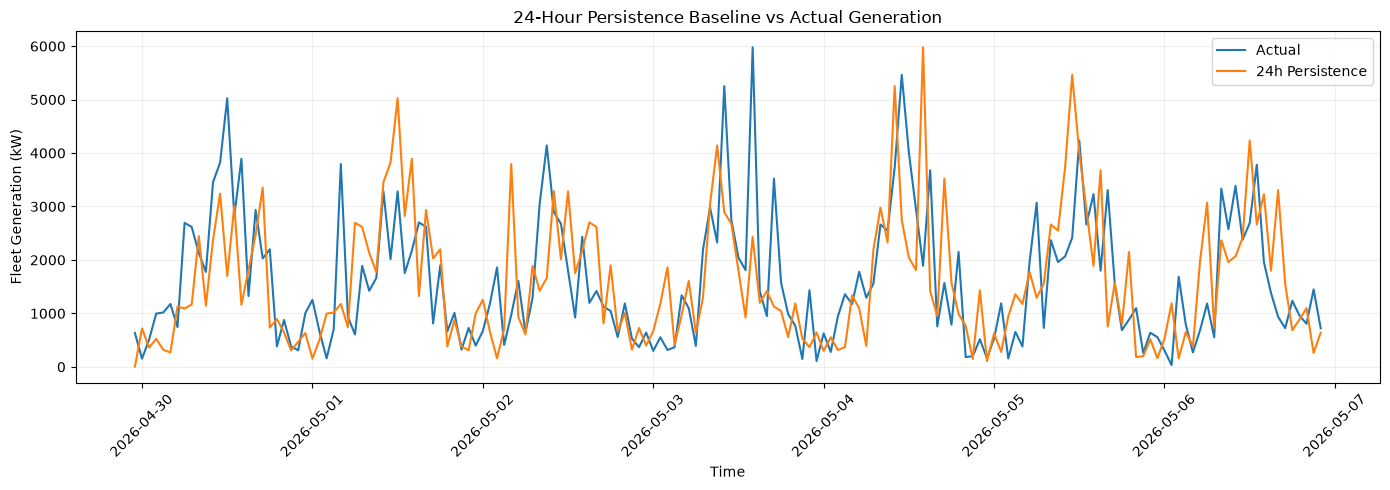

In [181]:
plot_data = baseline_test.iloc[:168]

plt.figure(figsize=(14, 5))

plt.plot(
    plot_data["timestamp"],
    plot_data["total_power_kw"],
    label="Actual"
)

plt.plot(
    plot_data["timestamp"],
    plot_data["persistence_prediction"],
    label="24h Persistence"
)

plt.xlabel("Time")
plt.ylabel("Fleet Generation (kW)")
plt.title("24-Hour Persistence Baseline vs Actual Generation")
plt.legend()
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Walk Forward Validation

In [182]:
features = [
    "lag_1",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "hour",
    "day_of_week"
]

target = "total_power_kw"

In [183]:
model_df = forecast_df[
    ["timestamp", target] + features
].copy()

model_df = model_df.dropna(
    subset=[target] + features
).reset_index(drop=True)

print("Rows available for modeling:", len(model_df))
print(model_df.head())

Rows available for modeling: 1923
            timestamp  total_power_kw  lag_1  lag_24  lag_48  lag_168  \
0 2026-03-08 00:00:00           217.1  835.1   731.3   552.7    655.7   
1 2026-03-08 01:00:00           337.5  217.1  1858.9   499.6    520.8   
2 2026-03-08 02:00:00           850.2  337.5   974.8  1594.5    234.3   
3 2026-03-08 03:00:00           623.6  850.2   719.3   910.2   1312.6   
4 2026-03-08 04:00:00           866.2  623.6  3376.9   811.7    752.6   

   rolling_mean_24  rolling_std_24  hour  day_of_week  
0      2478.600000     1998.205290     0            6  
1      2457.175000     2020.388135     1            6  
2      2393.783333     2063.385926     2            6  
3      2388.591667     2067.264554     3            6  
4      2384.604167     2070.713826     4            6  


In [188]:
evaluation_end = forecast_df["timestamp"].max()

# Last 28 complete days
evaluation_start = (
    evaluation_end.floor("D")
    - pd.Timedelta(days=27)
)

print("Evaluation start:", evaluation_start)
print("Evaluation end:", evaluation_end)

Evaluation start: 2026-05-02 00:00:00
Evaluation end: 2026-05-29 23:00:00


In [189]:
folds = []

fold_start = evaluation_start

while fold_start <= evaluation_end:

    fold_end = min(
        fold_start + pd.Timedelta(days=7) - pd.Timedelta(hours=1),
        evaluation_end
    )

    folds.append((fold_start, fold_end))

    fold_start = fold_end + pd.Timedelta(hours=1)

In [191]:
print("Rows available for modeling:", len(model_df))

Rows available for modeling: 1923


In [190]:
for i, (start, end) in enumerate(folds, 1):
    print(f"Fold {i}: {start} → {end}")

Fold 1: 2026-05-02 00:00:00 → 2026-05-08 23:00:00
Fold 2: 2026-05-09 00:00:00 → 2026-05-15 23:00:00
Fold 3: 2026-05-16 00:00:00 → 2026-05-22 23:00:00
Fold 4: 2026-05-23 00:00:00 → 2026-05-29 23:00:00


In [192]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

features = [
    "lag_1",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "hour",
    "day_of_week"
]

target = "total_power_kw"

In [193]:
walk_forward_results = []

for fold_number, (test_start, test_end) in enumerate(folds, 1):

    # -----------------------------
    # Training data = everything
    # before this test window
    # -----------------------------

    train_data = model_df[
        model_df["timestamp"] < test_start
    ].copy()

    # -----------------------------
    # Test data = current window
    # -----------------------------

    test_data = model_df[
        (model_df["timestamp"] >= test_start) &
        (model_df["timestamp"] <= test_end)
    ].copy()

    X_train = train_data[features]
    y_train = train_data[target]

    X_test = test_data[features]
    y_test = test_data[target]

    # -----------------------------
    # Train model
    # -----------------------------

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    # -----------------------------
    # Predict
    # -----------------------------

    predictions = model.predict(X_test)

    # -----------------------------
    # Store results
    # -----------------------------

    fold_results = test_data[
        ["timestamp", target]
    ].copy()

    fold_results["prediction"] = predictions
    fold_results["fold"] = fold_number

    walk_forward_results.append(
        fold_results
    )

    print(
        f"Fold {fold_number}: "
        f"Train={len(train_data)}, "
        f"Test={len(test_data)}"
    )

Fold 1: Train=1251, Test=168
Fold 2: Train=1419, Test=168
Fold 3: Train=1587, Test=168
Fold 4: Train=1755, Test=168


In [194]:
ml_results = pd.concat(
    walk_forward_results,
    ignore_index=True
)

print("Total predictions:", len(ml_results))
print(ml_results.head())
print(ml_results.tail())

Total predictions: 672
            timestamp  total_power_kw   prediction  fold
0 2026-05-02 00:00:00           669.2   814.074082     1
1 2026-05-02 01:00:00          1181.8   755.159631     1
2 2026-05-02 02:00:00          1860.2   777.785369     1
3 2026-05-02 03:00:00           410.3  1174.448019     1
4 2026-05-02 04:00:00           971.4  2522.800249     1
              timestamp  total_power_kw   prediction  fold
667 2026-05-29 19:00:00          1955.2  1575.711913     4
668 2026-05-29 20:00:00           729.2  1313.558116     4
669 2026-05-29 21:00:00           431.0  1116.712751     4
670 2026-05-29 22:00:00           556.7   889.403763     4
671 2026-05-29 23:00:00           283.0   792.222968     4


In [195]:
y_true_ml = ml_results["total_power_kw"]
y_pred_ml = ml_results["prediction"]

ml_mae = mean_absolute_error(
    y_true_ml,
    y_pred_ml
)

ml_rmse = np.sqrt(
    mean_squared_error(
        y_true_ml,
        y_pred_ml
    )
)

ml_mape = (
    np.mean(
        np.abs(
            (y_true_ml - y_pred_ml)
            / y_true_ml
        )
    ) * 100
)

print("Gradient Boosting")
print("-----------------")
print("MAE :", ml_mae)
print("RMSE:", ml_rmse)
print("MAPE:", ml_mape)

Gradient Boosting
-----------------
MAE : 666.2118633708275
RMSE: 874.415872423686
MAPE: 130.6448320787672


In [196]:
def smape(y_true, y_pred):
    denominator = (
        np.abs(y_true) +
        np.abs(y_pred)
    )

    mask = denominator != 0

    return (
        np.mean(
            2 * np.abs(
                y_pred[mask] - y_true[mask]
            ) / denominator[mask]
        )
        * 100
    )

In [197]:
ml_smape = smape(
    y_true_ml,
    y_pred_ml
)

print("sMAPE:", ml_smape)

sMAPE: 47.91270142873522


In [198]:
comparison = ml_results.merge(
    forecast_df[
        [
            "timestamp",
            "persistence_prediction"
        ]
    ],
    on="timestamp",
    how="left"
)

comparison = comparison.dropna(
    subset=["persistence_prediction"]
)

print("Comparable predictions:", len(comparison))

Comparable predictions: 672


In [201]:
baseline_mae = mean_absolute_error(
    comparison["total_power_kw"],
    comparison["persistence_prediction"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        comparison["total_power_kw"],
        comparison["persistence_prediction"]
    )
)

baseline_mape = (
    np.mean(
        np.abs(
            (
                comparison["total_power_kw"]
                - comparison["persistence_prediction"]
            )
            / comparison["total_power_kw"]
        )
    ) * 100
)

baseline_smape = smape(
    comparison["total_power_kw"].values,
    comparison["persistence_prediction"].values
)

print("24-Hour Persistence")
print("-------------------")
print("MAE  :", baseline_mae)
print("RMSE :", baseline_rmse)
print("MAPE :", baseline_mape)
print("sMAPE:", baseline_smape)

24-Hour Persistence
-------------------
MAE  : 846.2997023809525
RMSE : 1136.7739577077841
MAPE : 165.15437163122942
sMAPE: 60.245313363514796


In [202]:
results = pd.DataFrame({
    "Model": [
        "24-hour Persistence",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        ml_mae
    ],
    "RMSE": [
        baseline_rmse,
        ml_rmse
    ],
    "MAPE": [
        baseline_mape,
        ml_mape
    ],
    "sMAPE": [
        baseline_smape,
        ml_smape
    ]
})

results

,Model,MAE,RMSE,MAPE,sMAPE
0,24-hour Persistence,846.299702,1136.773958,165.154372,60.245313
1,Gradient Boosting,666.211863,874.415872,130.644832,47.912701


In [204]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
2,lag_48,0.250704
3,lag_168,0.250058
6,hour,0.156631
0,lag_1,0.145276
1,lag_24,0.131675
4,rolling_mean_24,0.050088
5,rolling_std_24,0.013564
7,day_of_week,0.002004


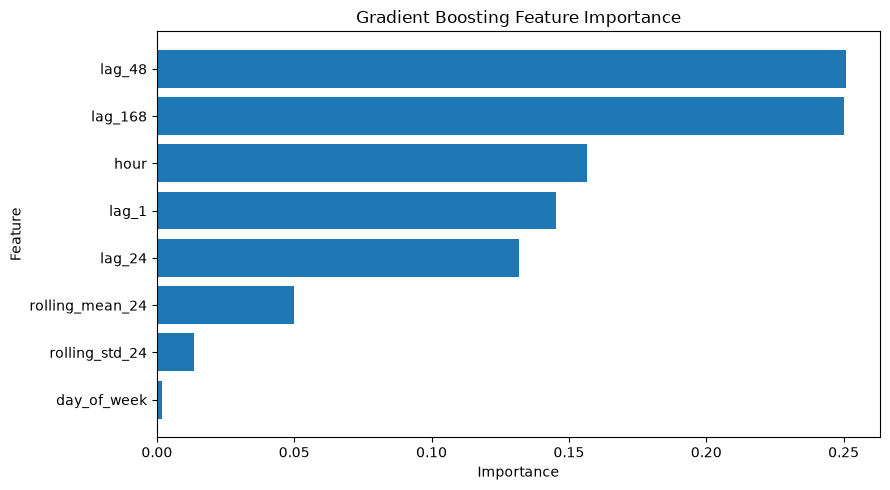

In [205]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [206]:
model.feature_importances_

array([0.14527611, 0.13167505, 0.25070437, 0.25005809, 0.05008765,
       0.01356407, 0.15663062, 0.00200403])

In [207]:
final_fold = ml_results[
    ml_results["fold"] == 4
].copy()

print(final_fold.shape)
print(final_fold.head())

(168, 4)
              timestamp  total_power_kw   prediction  fold
504 2026-05-23 00:00:00           210.3   742.983042     4
505 2026-05-23 01:00:00           679.0   622.040998     4
506 2026-05-23 02:00:00           292.9   797.218305     4
507 2026-05-23 03:00:00          1200.0   929.955485     4
508 2026-05-23 04:00:00          1257.8  1121.699339     4


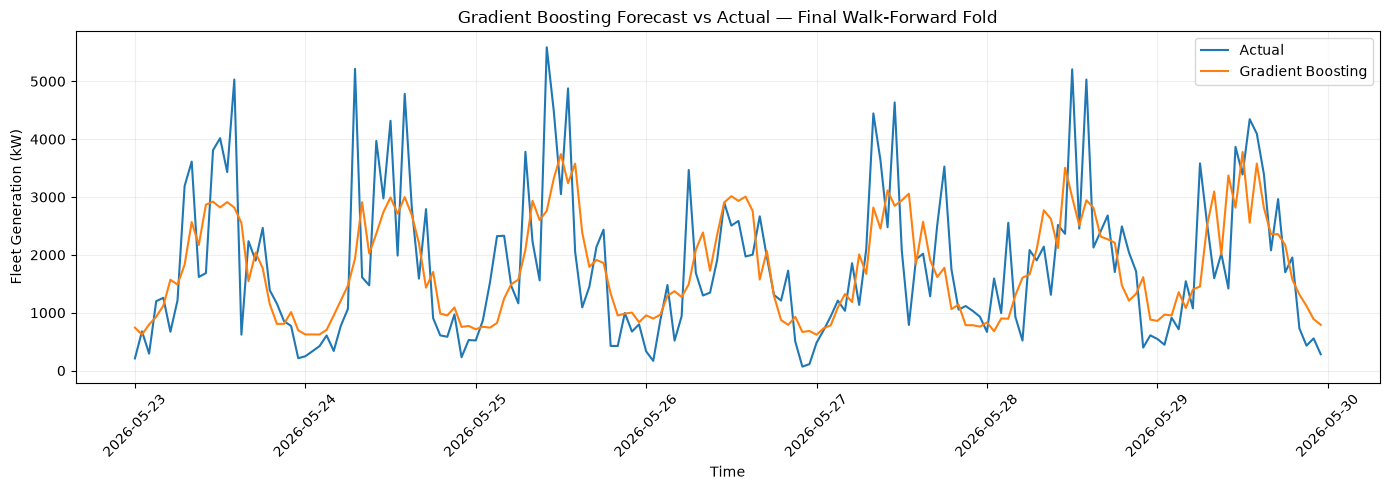

In [208]:
plt.figure(figsize=(14, 5))

plt.plot(
    final_fold["timestamp"],
    final_fold["total_power_kw"],
    label="Actual"
)

plt.plot(
    final_fold["timestamp"],
    final_fold["prediction"],
    label="Gradient Boosting"
)

plt.xlabel("Time")
plt.ylabel("Fleet Generation (kW)")
plt.title(
    "Gradient Boosting Forecast vs Actual — Final Walk-Forward Fold"
)

plt.legend()
plt.grid(alpha=0.2)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [209]:
final_fold["residual"] = (
    final_fold["total_power_kw"]
    - final_fold["prediction"]
)

print(
    final_fold["residual"].describe()
)

count     168.000000
mean       54.426807
std       929.542168
min     -2268.609238
25%      -529.165438
50%      -113.262944
75%       517.137565
max      3280.371169
Name: residual, dtype: float64


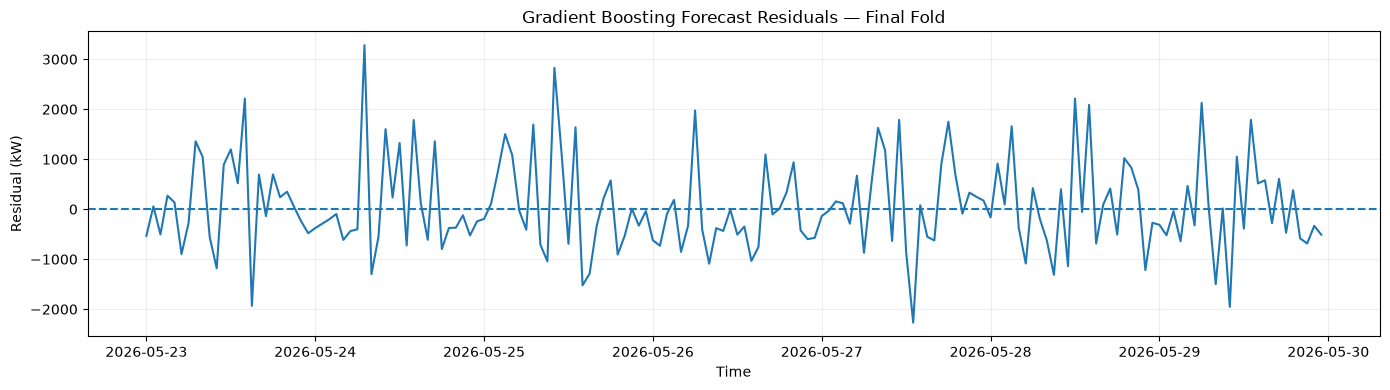

In [210]:
plt.figure(figsize=(14, 4))

plt.plot(
    final_fold["timestamp"],
    final_fold["residual"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time")
plt.ylabel("Residual (kW)")
plt.title("Gradient Boosting Forecast Residuals — Final Fold")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

The model captures the general temporal pattern well, but it tends to smooth sudden generation spikes. The residuals have a large spread, indicating that abrupt changes in generation remain difficult to predict using historical generation and calendar features alone. This is expected because the model doesn't have access to future meteorological forecasts.

In [211]:
fold_metrics = []

for fold_number in sorted(ml_results["fold"].unique()):

    fold_ml = ml_results[
        ml_results["fold"] == fold_number
    ].copy()

    fold_comparison = fold_ml.merge(
        forecast_df[
            ["timestamp", "persistence_prediction"]
        ],
        on="timestamp",
        how="left"
    ).dropna(
        subset=["persistence_prediction"]
    )

    y_true = fold_comparison["total_power_kw"]

    # Gradient Boosting
    ml_pred = fold_comparison["prediction"]

    ml_mae = mean_absolute_error(
        y_true,
        ml_pred
    )

    ml_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            ml_pred
        )
    )

    # Persistence
    baseline_pred = (
        fold_comparison["persistence_prediction"]
    )

    baseline_mae = mean_absolute_error(
        y_true,
        baseline_pred
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            baseline_pred
        )
    )

    fold_metrics.append({
        "fold": fold_number,
        "baseline_mae": baseline_mae,
        "gb_mae": ml_mae,
        "baseline_rmse": baseline_rmse,
        "gb_rmse": ml_rmse
    })

fold_metrics_df = pd.DataFrame(
    fold_metrics
)

fold_metrics_df

,fold,baseline_mae,gb_mae,baseline_rmse,gb_rmse
0,1,883.579762,710.229653,1185.374289,899.148469
1,2,689.480952,600.691262,972.676142,824.374109
2,3,874.877381,649.186092,1151.144077,841.714950
3,4,937.260714,704.740446,1221.751347,928.368339


In [212]:
fold_metrics_df["MAE_improvement_%"] = (
    (
        fold_metrics_df["baseline_mae"]
        - fold_metrics_df["gb_mae"]
    )
    / fold_metrics_df["baseline_mae"]
    * 100
)

fold_metrics_df["RMSE_improvement_%"] = (
    (
        fold_metrics_df["baseline_rmse"]
        - fold_metrics_df["gb_rmse"]
    )
    / fold_metrics_df["baseline_rmse"]
    * 100
)

fold_metrics_df

,fold,baseline_mae,gb_mae,baseline_rmse,gb_rmse,MAE_improvement_%,RMSE_improvement_%
0,1,883.579762,710.229653,1185.374289,899.148469,19.619067,24.146451
1,2,689.480952,600.691262,972.676142,824.374109,12.877758,15.246805
2,3,874.877381,649.186092,1151.144077,841.714950,25.796905,26.880139
3,4,937.260714,704.740446,1221.751347,928.368339,24.808494,24.013316


Gradient Boosting consistently outperformed the 24-hour persistence baseline across all four walk-forward evaluation windows. MAE improvement ranged from 12.9% to 25.8%, while RMSE improvement ranged from 15.2% to 26.9%. This indicates that incorporating multiple historical lags, rolling statistics, and calendar features provides useful predictive information beyond simply using the previous day's generation.

In [214]:
final_results = ml_results.merge(
    forecast_df[
        [
            "timestamp",
            "persistence_prediction"
        ]
    ],
    on="timestamp",
    how="left"
)

final_results = final_results.rename(
    columns={
        "total_power_kw": "actual_power_kw",
        "prediction": "gradient_boosting_prediction_kw",
        "persistence_prediction": "persistence_prediction_kw"
    }
)

final_results.to_csv(
    "../data_pack/forecast_results.csv",
    index=False
)

print("Forecast results saved.")
print(final_results.head())

Forecast results saved.
            timestamp  actual_power_kw  gradient_boosting_prediction_kw  fold  \
0 2026-05-02 00:00:00            669.2                       814.074082     1   
1 2026-05-02 01:00:00           1181.8                       755.159631     1   
2 2026-05-02 02:00:00           1860.2                       777.785369     1   
3 2026-05-02 03:00:00            410.3                      1174.448019     1   
4 2026-05-02 04:00:00            971.4                      2522.800249     1   

   persistence_prediction_kw  
0                     1254.4  
1                      658.5  
2                      159.0  
3                      706.8  
4                     3794.0  


In [215]:
fold_metrics_df.to_csv(
    "../data_pack/fold_metrics.csv",
    index=False
)

print("Fold metrics saved.")

Fold metrics saved.


In [216]:
# Final training data
final_train = model_df[
    model_df["timestamp"] < evaluation_start
].copy()

X_final_train = final_train[features]
y_final_train = final_train[target]

print("Final training rows:", len(final_train))
print("Training period:")
print(final_train["timestamp"].min())
print("→")
print(final_train["timestamp"].max())

Final training rows: 1251
Training period:
2026-03-08 00:00:00
→
2026-05-01 23:00:00


In [217]:
final_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_model.fit(
    X_final_train,
    y_final_train
)

print("Final Gradient Boosting model trained successfully.")

Final Gradient Boosting model trained successfully.


In [218]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

In [219]:
model_path = "../models/gradient_boosting_model.pkl"

joblib.dump(
    final_model,
    model_path
)

print(f"Model saved to: {model_path}")

Model saved to: ../models/gradient_boosting_model.pkl


In [220]:
overall_results = pd.DataFrame({
    "Model": [
        "24-hour Persistence",
        "Gradient Boosting"
    ],
    "MAE_kW": [
        baseline_mae,
        ml_mae
    ],
    "RMSE_kW": [
        baseline_rmse,
        ml_rmse
    ],
    "MAPE_percent": [
        baseline_mape,
        ml_mape
    ],
    "sMAPE_percent": [
        baseline_smape,
        ml_smape
    ]
})

overall_results

,Model,MAE_kW,RMSE_kW,MAPE_percent,sMAPE_percent
0,24-hour Persistence,937.260714,1221.751347,165.154372,60.245313
1,Gradient Boosting,704.740446,928.368339,130.644832,47.912701


In [221]:
overall_results.to_csv(
    "../data_pack/model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


In [223]:
print("Final model features:")
print(features)

print("\nEvaluation results:")
display(overall_results)

print("\nWalk-forward results:")
display(fold_metrics_df)

Final model features:
['lag_1', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'hour', 'day_of_week']

Evaluation results:


,Model,MAE_kW,RMSE_kW,MAPE_percent,sMAPE_percent
0,24-hour Persistence,937.260714,1221.751347,165.154372,60.245313
1,Gradient Boosting,704.740446,928.368339,130.644832,47.912701



Walk-forward results:


,fold,baseline_mae,gb_mae,baseline_rmse,gb_rmse,MAE_improvement_%,RMSE_improvement_%
0,1,883.579762,710.229653,1185.374289,899.148469,19.619067,24.146451
1,2,689.480952,600.691262,972.676142,824.374109,12.877758,15.246805
2,3,874.877381,649.186092,1151.144077,841.714950,25.796905,26.880139
3,4,937.260714,704.740446,1221.751347,928.368339,24.808494,24.013316


In [224]:
# Actual values
y_true = final_results["actual_power_kw"]

# Gradient Boosting predictions
y_gb = final_results["gradient_boosting_prediction_kw"]

# Persistence predictions
y_persistence = final_results["persistence_prediction_kw"]


# -----------------------------
# Gradient Boosting
# -----------------------------

gb_mae = mean_absolute_error(
    y_true,
    y_gb
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_gb
    )
)

gb_mape = (
    np.mean(
        np.abs(
            (y_true - y_gb) / y_true
        )
    ) * 100
)

gb_smape = smape(
    y_true.values,
    y_gb.values
)


# -----------------------------
# Persistence
# -----------------------------

persistence_mae = mean_absolute_error(
    y_true,
    y_persistence
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_persistence
    )
)

persistence_mape = (
    np.mean(
        np.abs(
            (y_true - y_persistence) / y_true
        )
    ) * 100
)

persistence_smape = smape(
    y_true.values,
    y_persistence.values
)

In [225]:
overall_results = pd.DataFrame({
    "Model": [
        "24-hour Persistence",
        "Gradient Boosting"
    ],
    "MAE_kW": [
        persistence_mae,
        gb_mae
    ],
    "RMSE_kW": [
        persistence_rmse,
        gb_rmse
    ],
    "MAPE_percent": [
        persistence_mape,
        gb_mape
    ],
    "sMAPE_percent": [
        persistence_smape,
        gb_smape
    ]
})

overall_results

,Model,MAE_kW,RMSE_kW,MAPE_percent,sMAPE_percent
0,24-hour Persistence,846.299702,1136.773958,165.154372,60.245313
1,Gradient Boosting,666.211863,874.415872,130.644832,47.912701


In [226]:
mae_improvement = (
    (persistence_mae - gb_mae)
    / persistence_mae
    * 100
)

rmse_improvement = (
    (persistence_rmse - gb_rmse)
    / persistence_rmse
    * 100
)

print(f"Overall MAE improvement: {mae_improvement:.2f}%")
print(f"Overall RMSE improvement: {rmse_improvement:.2f}%")

Overall MAE improvement: 21.28%
Overall RMSE improvement: 23.08%
